# Adjoint Solver for Spring-Slider Rate-and-State Friction

Extends the existing `springslider.ipynb` forward solver with an adjoint-based gradient computation.

**Setup:** Velocity-strengthening friction (`a > b`), afterslip problem, adaptive-step RK.

**State evolution:** Slip law — matches the existing forward solver exactly.

**Force balance convention:**
$$\tau(V,\psi) + \eta V + k u = \tau_0$$

**Objective function (smoothed-slip misfit):**
$$J = \frac{1}{2}\int_0^T \left(Su - Su_{\rm obs}\right)^2 dt$$

where $S$ is a temporal Gaussian smoothing operator (row-normalised) and $u$ is the cumulative slip.

**Adjoint system** ($u^\dagger = p$, $\psi^\dagger = r$, BCs $p(T)=r(T)=0$)**:**

From the three adjoint equations (derived via Lagrangian with smoothed misfit):
$$\delta u:\quad \dot{u}^\dagger = -V^\dagger + \bigl[S^\top(Su - Su_{\rm obs})\bigr](t)$$
$$\delta\psi:\quad \dot{\psi}^\dagger = -\tau_\psi\,V^\dagger - G_\psi\,\psi^\dagger$$
$$\delta V:\quad (\tau_V + \eta)\,V^\dagger = -k\,u^\dagger - \psi^\dagger\,G_V$$

The adjoint solver integrates these equations **forwards in reversed time** $\tau = T - t$ and then re-inverts $\tau$ at the end.

**Gradient:**
$$\frac{dJ}{da} = \int_0^T \left[-V^\dagger\,\frac{\partial\tau}{\partial a} - \psi^\dagger\,\frac{\partial G}{\partial a}\right]dt$$

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import scipy.sparse

## Physics: Friction Law and Jacobians

**Regularised RS friction (slip-law form used in original code):**
$$\tau(V,\psi) = N a\,\sinh^{-1}\!\left(\frac{V}{2V_0}e^{\psi/a}\right)$$

**State evolution — slip law:**
$$G(V,\psi) = -\frac{V}{D_c}\left(\frac{\tau}{N} - f_{\rm ss}\right), \quad f_{\rm ss} = f_0 + (a-b)\ln(V/V_0)$$

Partial derivatives are derived analytically.

In [64]:
# ------------------------------------------------------------------
# Friction law
# ------------------------------------------------------------------

def xi_fn(V, psi, M):
    """Argument of arcsinh: xi = V/(2*V0) * exp(psi/a)."""
    return V / (2.0 * M['V0']) * np.exp(psi / M['a'])

def tau_fn(V, psi, M):
    """Frictional strength (MPa)."""
    return M['N'] * M['a'] * np.arcsinh(xi_fn(V, psi, M))

def fss_fn(V, M):
    """Steady-state friction coefficient."""
    return M['f0'] + (M['a'] - M['b']) * np.log(V / M['V0'])

def G_fn(V, psi, M):
    """State evolution dpsi/dt (slip law)."""
    f = tau_fn(V, psi, M) / M['N']
    return -V / M['dc'] * (f - fss_fn(V, M))

# ------------------------------------------------------------------
# Partial derivatives
# ------------------------------------------------------------------

def tau_V_fn(V, psi, M):
    """dtau/dV = N*a / sqrt(1+xi^2) * xi/V."""
    xi = xi_fn(V, psi, M)
    return M['N'] * M['a'] / np.sqrt(1.0 + xi**2) * xi / V

def tau_psi_fn(V, psi, M):
    """dtau/dpsi = N * xi / sqrt(1+xi^2)."""
    xi = xi_fn(V, psi, M)
    return M['N'] * xi / np.sqrt(1.0 + xi**2)

def G_V_fn(V, psi, M):
    """
    dG/dV for slip law.
    G = -(V/dc)*(tau/N - fss), so
    dG/dV = G/V - V*tau_V/(dc*N) + (a-b)/dc
    """
    G  = G_fn(V, psi, M)
    tV = tau_V_fn(V, psi, M)
    return G / V - V * tV / (M['dc'] * M['N']) + (M['a'] - M['b']) / M['dc']

def G_psi_fn(V, psi, M):
    """dG/dpsi = -V * tau_psi / (dc * N)."""
    tP = tau_psi_fn(V, psi, M)
    return -V * tP / (M['dc'] * M['N'])

def dtau_da_fn(V, psi, M):
    """
    Explicit partial dtau/da  (holding V, psi fixed).
    tau = N*a*arcsinh(xi),  xi = V/(2*V0)*exp(psi/a)
    d(tau)/da = N*arcsinh(xi) - N*psi*xi / (a*sqrt(1+xi^2))
    """
    xi = xi_fn(V, psi, M)
    return M['N'] * np.arcsinh(xi) - M['N'] * psi * xi / (M['a'] * np.sqrt(1.0 + xi**2))

def dG_da_fn(V, psi, M):
    """
    Explicit partial dG/da  (holding V, psi fixed).
    G = -(V/dc)*(tau/N - fss),  dfss/da = ln(V/V0)
    dG/da = -(V/dc)*(dtau_da/N - ln(V/V0))
    """
    dtau = dtau_da_fn(V, psi, M)
    return -(V / M['dc']) * (dtau / M['N'] - np.log(V / M['V0']))

print("Physics functions defined.")

Physics functions defined.


## Parameters and Afterslip Initial Conditions

Velocity-strengthening (`a > b`) with a coseismic stress step $\Delta\tau$ at $t=0$.

In [65]:
# ------------------------------------------------------------------
# Force-balance solver:  tau(V,psi) + eta*V + k*u = tau_L  =>  V
# ------------------------------------------------------------------

def solve_V_algebraic(u, psi, M, tau_L):
    """
    Root-find V from  tau(V,psi) + eta*V = tau_L - k*u.
    tau_L is the current loading stress (may vary with time).
    """
    rhs = tau_L - M['k'] * u
    if rhs <= 0.0:
        raise ValueError(f"Force-balance RHS = {rhs:.4g} <= 0; check tau_L and k*u.")
    def res(V):
        return tau_fn(V, psi, M) + M['eta'] * V - rhs
    Vmin = 1e-30
    Vmax = rhs / M['eta']
    return brentq(res, Vmin, Vmax, xtol=1e-20, rtol=1e-10)

# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------
M = {}
M['f0']  = 0.6
M['V0']  = 1e-6      # m/s reference velocity
M['a']   = 0.010     # direct effect  (a > b → velocity strengthening)
M['b']   = 0.015     # state evolution
M['dc']  = 1e-4      # m critical slip distance
M['N']   = 50.0      # MPa effective normal stress
M['eta'] = 2.7 * 3.5 / 2.0   # MPa·s/m radiation damping
# M['k']   = 2e4       # MPa/m spring stiffness
k_crit = M['N'] * (M['b'] - M['a']) / M['dc']
M['k'] = 1e2

V_bg      = 1e-9     # m/s background / plate sliding rate
M['V_bg'] = V_bg

# ------------------------------------------------------------------
# Steady-state at V_bg
# ------------------------------------------------------------------
fss_bg = fss_fn(V_bg, M)
psi_ss = M['a'] * np.log(2.0 * M['V0'] / V_bg * np.sinh(fss_bg / M['a']))
tau_ss = M['N'] * fss_bg

# ------------------------------------------------------------------
# Initial conditions — V_init is the PRIMARY control parameter.
# tau0 is DERIVED from the force balance at t=0 (u=0):
#   tau(V_init, psi_init) + eta*V_init = tau0
# This ensures the forward solver starts at exactly V_init.
# ------------------------------------------------------------------
V_init   = 1.0e-9      # m/s  post-earthquake initial slip rate
psi_init = psi_ss    # pre-earthquake steady state at V_bg
u_init   = 0.0

M['tau0'] = tau_fn(V_init, psi_init, M) + M['eta'] * V_init
Delta_tau = M['tau0'] - tau_ss   # implied coseismic stress step (diagnostic)

# Characteristic afterslip time  T_c ~ N*a / (k * V_init)
T_c = M['N'] * M['a'] / (M['k'] * V_init)

print(f"a={M['a']}, b={M['b']}  →  velocity {'strengthening' if M['a']>M['b'] else 'weakening'}")
print(f"V_bg   = {V_bg:.2e} m/s,   V_init = {V_init:.2e} m/s  (ratio {V_init/V_bg:.1f}×)")
print(f"psi_ss = {psi_ss:.4f}")
print(f"tau_ss = {tau_ss:.4f} MPa")
print(f"tau0   = {M['tau0']:.4f} MPa  (Delta_tau = {Delta_tau:.4f} MPa)")
print(f"T_c    = {T_c:.3e} s  ({T_c/86400:.1f} days)")
print(f"k      = {M['k']:.2e} MPa/m,   k_crit = {k_crit:.2e} MPa/m  (k/k_crit = {M['k']/k_crit:.2f})")

a=0.01, b=0.015  →  velocity weakening
V_bg   = 1.00e-09 m/s,   V_init = 1.00e-09 m/s  (ratio 1.0×)
psi_ss = 0.7036
tau_ss = 31.7269 MPa
tau0   = 31.7269 MPa  (Delta_tau = 0.0000 MPa)
T_c    = 5.000e+06 s  (57.9 days)
k      = 1.00e+02 MPa/m,   k_crit = 2.50e+03 MPa/m  (k/k_crit = 0.04)


## Adaptive Forward Solver

Uses a 3-stage embedded RK method (2nd/3rd-order pair) for automatic step-size control,
matching the MATLAB reference implementation.

**Method:** Three stages per trial step; accept if $\|[\Delta u,\,\Delta\psi]\|_2 < \text{tol}$;
adjust $\Delta t \leftarrow \sigma\,\Delta t\,(\text{tol}/e)^{1/3}$ where $\sigma=0.9$ is a safety factor.


In [66]:
def forward_solve_adaptive(M, T, u0, psi0, V_init=None,
                           tol=1e-4, dt0=1.0, dtmax=1e5, safety=0.9):
    """
    Adaptive-step forward solve using a 3-stage embedded RK method
    (2nd/3rd-order error-control pair, matching the MATLAB reference).

    Loading: tau_L(t) = tau0 + k*V_bg*t
    ODE:     du/dt = V,   dpsi/dt = G(V,psi)
    Algebraic: tau(V,psi) + eta*V + k*u = tau_L(t)  =>  V
    """
    tau_L_fn = lambda t: M['tau0'] + M['k'] * M['V_bg'] * t

    V0 = solve_V_algebraic(u0, psi0, M, tau_L_fn(0.0))
    if V_init is not None:
        rel_err = abs(V0 - V_init) / V_init
        assert rel_err < 1e-6, (
            f"Init mismatch: V(0)={V0:.6e}, V_init={V_init:.6e} (rel={rel_err:.2e})"
        )

    def _rhs(u_v, psi_v, t_v):
        V = solve_V_algebraic(u_v, psi_v, M, tau_L_fn(t_v))
        return V, G_fn(V, psi_v, M)

    def _jac(V, psi):
        return (tau_V_fn(V,psi,M), tau_psi_fn(V,psi,M),
                G_V_fn(V,psi,M),   G_psi_fn(V,psi,M),
                dtau_da_fn(V,psi,M), dG_da_fn(V,psi,M))

    # Initialise storage
    t_arr = [0.0]; u_arr = [u0]; psi_arr = [psi0]
    V_arr = [V0];  tauL_arr = [tau_L_fn(0.0)]
    j = _jac(V0, psi0)
    tV_arr=[j[0]]; tP_arr=[j[1]]; GV_arr=[j[2]]
    GP_arr=[j[3]]; da_arr=[j[4]]; dGa_arr=[j[5]]

    t = 0.0; u = u0; psi = psi0; dt = dt0
    V1, G1 = V0, G_fn(V0, psi0, M)   # stage-1 values at t=0

    while t < T:
        if t + dt > T:
            dt = T - t

        # --- three-stage embedded RK ---
        V2, G2 = _rhs(u + 0.5*dt*V1,         psi + 0.5*dt*G1,         t + 0.5*dt)
        V3, G3 = _rhs(u + dt*(-V1 + 2.0*V2), psi + dt*(-G1 + 2.0*G2), t +     dt)

        u2   = u   + dt/2.0*(V1 + V3)            # 2nd-order update
        psi2 = psi + dt/2.0*(G1 + G3)
        u3   = u   + dt/6.0*(V1 + 4.0*V2 + V3)  # 3rd-order update
        psi3 = psi + dt/6.0*(G1 + 4.0*G2 + G3)

        er = np.sqrt((u2 - u3)**2 + (psi2 - psi3)**2)

        if er < tol:
            t += dt;  u = u3;  psi = psi3
            tL    = tau_L_fn(t)
            V_new = solve_V_algebraic(u, psi, M, tL)

            t_arr.append(t);     u_arr.append(u);    psi_arr.append(psi)
            V_arr.append(V_new); tauL_arr.append(tL)
            j = _jac(V_new, psi)
            tV_arr.append(j[0]); tP_arr.append(j[1]); GV_arr.append(j[2])
            GP_arr.append(j[3]); da_arr.append(j[4]); dGa_arr.append(j[5])

            V1 = V_new;  G1 = G_fn(V_new, psi, M)  # stage-1 for next step

        # Step-size control  (q=2 → exponent 1/3)
        dt = safety * dt * (tol / er)**(1.0/3.0) if er > 0.0 else dtmax
        dt = min(dt, dtmax)

    return dict(
        t       = np.array(t_arr),
        u       = np.array(u_arr),
        psi     = np.array(psi_arr),
        V       = np.array(V_arr),
        tau_L   = np.array(tauL_arr),
        tau_V   = np.array(tV_arr),
        tau_psi = np.array(tP_arr),
        G_V     = np.array(GV_arr),
        G_psi   = np.array(GP_arr),
        dtau_da = np.array(da_arr),
        dG_da   = np.array(dGa_arr),
    )

# --- Run adaptive forward solve ---
T = 5e8    # s
print(f"Running adaptive forward solve: T={T:.1e} s ...")
fwd = forward_solve_adaptive(M, T, u_init, psi_init, V_init=V_init)
print(f"Done.  Steps={len(fwd['t'])-1},  V(0)={fwd['V'][0]:.6e},  V(T)={fwd['V'][-1]:.3e} m/s")
print(f"tau_L: {fwd['tau_L'][0]:.4f} → {fwd['tau_L'][-1]:.4f} MPa")


Running adaptive forward solve: T=5.0e+08 s ...
Done.  Steps=8249,  V(0)=1.000000e-09,  V(T)=2.550e-12 m/s
tau_L: 31.7269 → 81.7269 MPa


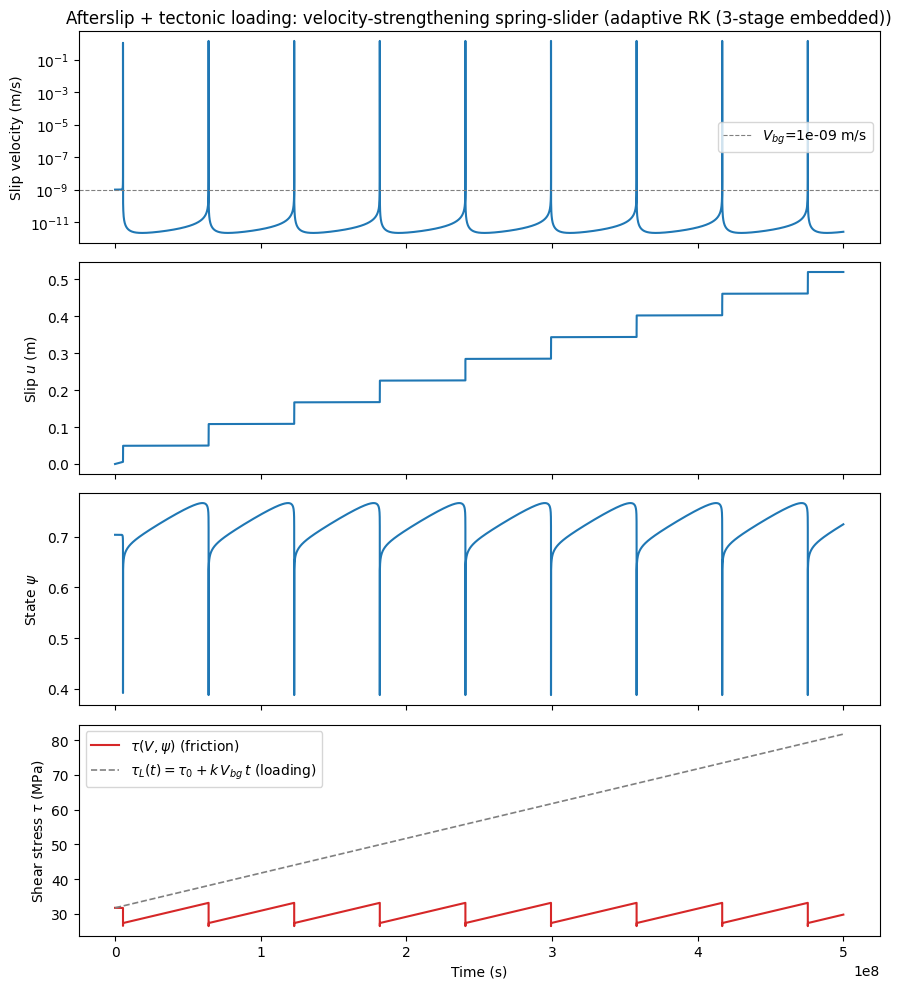

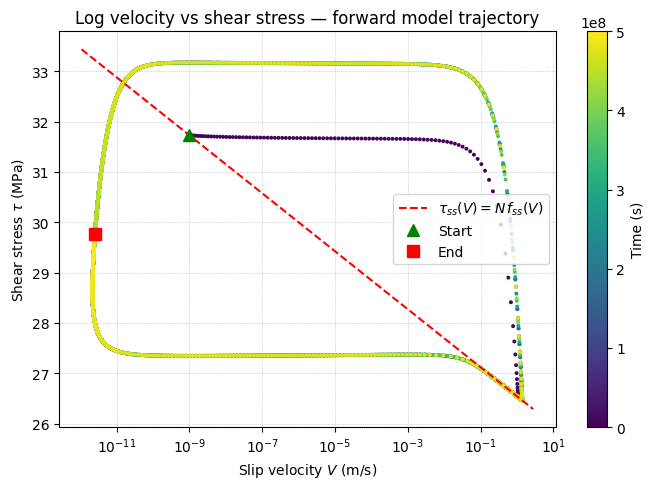

tau range: 26.4627 – 33.1700 MPa
V   range: 2.166e-12 – 1.396e+00 m/s


In [67]:
# ------------------------------------------------------------------
# Plot 1: Forward solution
# ------------------------------------------------------------------
tau_fwd = np.array([tau_fn(v, p, M) for v, p in zip(fwd['V'], fwd['psi'])])

fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

axes[0].plot(fwd['t'], fwd['V'])
axes[0].axhline(V_bg, color='gray', ls='--', lw=0.8, label=f'$V_{{bg}}$={V_bg:.0e} m/s')
axes[0].set_ylabel('Slip velocity (m/s)')
axes[0].set_yscale('log')
axes[0].set_title('Afterslip + tectonic loading: velocity-strengthening spring-slider (adaptive RK (3-stage embedded))')
axes[0].legend()

axes[1].plot(fwd['t'], fwd['u'])
axes[1].set_ylabel('Slip $u$ (m)')

axes[2].plot(fwd['t'], fwd['psi'])
axes[2].set_ylabel('State $\\psi$')

axes[3].plot(fwd['t'], tau_fwd, color='C3', label=r'$\tau(V,\psi)$ (friction)')
axes[3].plot(fwd['t'], fwd['tau_L'], color='gray', ls='--', lw=1.2,
             label=r'$\tau_L(t) = \tau_0 + k\,V_{bg}\,t$ (loading)')
axes[3].set_ylabel('Shear stress $\\tau$ (MPa)')
axes[3].set_xlabel('Time (s)')
axes[3].legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Plot 1c: Log velocity vs shear stress (phase portrait)
# ------------------------------------------------------------------
V_min = fwd['V'].min() * 0.5
V_max = fwd['V'].max() * 2.0
V_ss  = np.geomspace(V_min, V_max, 300)
tau_ss_line = M['N'] * fss_fn(V_ss, M)

fig3, ax3 = plt.subplots(figsize=(7, 5))
sc = ax3.scatter(fwd['V'], tau_fwd, c=fwd['t'], cmap='viridis',
                 s=8, lw=0, zorder=3)
ax3.plot(V_ss, tau_ss_line, 'r--', lw=1.5, zorder=4,
         label=r'$\tau_{ss}(V) = N\,f_{ss}(V)$')
ax3.set_xscale('log')
ax3.set_ylabel('Shear stress $\\tau$ (MPa)')
ax3.set_xlabel('Slip velocity $V$ (m/s)')
ax3.set_title('Log velocity vs shear stress — forward model trajectory')
cbar = fig3.colorbar(sc, ax=ax3)
cbar.set_label('Time (s)')
ax3.plot(fwd['V'][0],  tau_fwd[0],  'g^', ms=8, zorder=5, label='Start')
ax3.plot(fwd['V'][-1], tau_fwd[-1], 'rs', ms=8, zorder=5, label='End')
ax3.legend()
ax3.grid(True, ls=':', lw=0.5, which='both')
plt.tight_layout()
plt.show()

print(f"tau range: {tau_fwd.min():.4f} – {tau_fwd.max():.4f} MPa")
print(f"V   range: {fwd['V'].min():.3e} – {fwd['V'].max():.3e} m/s")

In [78]:
# ------------------------------------------------------------------
# Gaussian smoothing matrix
# ------------------------------------------------------------------

def make_smoothing_matrix(t, sigma):
    """
    Row-normalised Gaussian smoothing matrix on an arbitrary time grid.

    S[i, j] = exp(-(t[i] - t[j])^2 / (2*sigma^2))  then row-normalised.

    Forms a dense (n x n) array — keep sigma modest relative to n*dt_max
    if memory is a concern.
    """
    diff2 = (t[:, None] - t[None, :]) ** 2 / (2.0 * sigma ** 2)
    S = np.exp(-diff2)
    S /= S.sum(axis=1, keepdims=True)
    S = np.identity(len(t))
    return S

# Smoothing length scale — 5% of the total simulation duration
sigma_smooth = 0.01 * T
print(f"Smoothing σ = {sigma_smooth:.2e} s  ({sigma_smooth / 86400:.0f} days)")

Smoothing σ = 5.00e+06 s  (58 days)


## Adjoint Solver — Forward-in-Reversed-Time Crank–Nicolson

We use the **discrete adjoint** on the stored forward time grid (no new adaptive stepping).  
The adjoint is integrated **forwards in reversed time** $\tau = T - t$, then the output arrays are flipped back to the original time order.

**Why Crank–Nicolson?**  
$G_\psi = -V\tau_\psi/(D_c N) < 0$ always, so the $r$-adjoint grows exponentially in backward time. Explicit methods blow up when $h|G_\psi| > 2$.  
Crank–Nicolson (implicit trapezoidal) has amplification factor $|(1-h\mu/2)/(1+h\mu/2)| < 1$ for all $\mu > 0$ — **unconditionally A-stable**.

**Forward-in-$\tau$ ODE** (reversed-time index $j = 0 \to n-1$, IC $p=r=0$ at $j=0$):
$$\frac{dp}{d\tau} = A\,p + B\,r - \mathrm{sm}(T-\tau), \qquad
  \frac{dr}{d\tau} = \tau_\psi A\,p + (\tau_\psi B + G_\psi)\,r$$

where $A = -k/(\tau_V+\eta)$, $B = -G_V/(\tau_V+\eta)$, and $\mathrm{sm} = S^\top(Su - Su_{\rm obs})$.

**CN forward step** $j \to j+1$ ($\Delta\tau = t_j^{\rm rev} - t_{j+1}^{\rm rev} > 0$, $h = \Delta\tau/2$):
$$(\mathbf{I} - h\,\mathbf{M}_{j+1})\,\mathbf{y}_{j+1}
  = (\mathbf{I} + h\,\mathbf{M}_j)\,\mathbf{y}_j + h\,(\mathbf{b}_j + \mathbf{b}_{j+1})$$

where $\mathbf{M} = \bigl[\begin{smallmatrix}A & B \\ \tau_\psi A & \tau_\psi B + G_\psi\end{smallmatrix}\bigr]$, $\mathbf{b} = [-\mathrm{sm},\, 0]^\top$.  
The LHS is $2\times2$ and solved analytically.  
At the end the arrays are reversed to recover $(p(t), r(t))$ in original time order.

In [79]:
def adjoint_solve(fwd, t_obs, u_obs, M, sigma):
    """
    Discrete adjoint on the forward adaptive time grid using Crank-Nicolson,
    integrated **forwards in reversed time** τ = T - t.

    Smoothed misfit source: sm = S^T(Su - Su_obs),  S = Gaussian(t, sigma).

    Forward-in-τ ODE  (IC: p=r=0 at τ=0, i.e. t=T):
        dp/dτ =  A*p + B*r − sm(T−τ)
        dr/dτ =  τ_ψ*A*p + (τ_ψ*B + G_ψ)*r
        V†    =  A*p + B*r,   A = −k/(τ_V+η),   B = −G_V/(τ_V+η)

    CN forward step j → j+1  (Δτ = t_rev[j] − t_rev[j+1] > 0, h = Δτ/2):
        (I − h·M_{j+1}) y_{j+1} = (I + h·M_j) y_j + h·(b_j + b_{j+1})
    where M = [[A, B], [τ_ψ A, τ_ψ B + G_ψ]],  b = [−sm, 0].
    The 2×2 LHS is solved analytically.

    At the end, arrays are reversed to recover p(t), r(t) in original time order.
    """
    k   = M['k']
    eta = M['eta']
    n   = len(fwd['t'])

    # --- smoothed misfit: S^T (S u − S u_obs) ---
    S             = make_smoothing_matrix(fwd['t'], sigma)
    u_obs_at_fwd  = np.interp(fwd['t'], t_obs, u_obs)
    smooth_misfit = S.T @ (S @ fwd['u'] - S @ u_obs_at_fwd)   # shape (n,)

    # --- reverse arrays so index 0 = t=T, index n-1 = t=0 ---
    rev  = slice(None, None, -1)
    tV_r = fwd['tau_V'][rev]
    tP_r = fwd['tau_psi'][rev]
    GV_r = fwd['G_V'][rev]
    GP_r = fwd['G_psi'][rev]
    sm_r = smooth_misfit[rev]
    t_r  = fwd['t'][rev]

    p_r = np.zeros(n)   # IC at τ=0 (t=T)
    r_r = np.zeros(n)

    for j in range(n - 1):
        dt_tau = t_r[j] - t_r[j + 1]   # > 0  (t_r is decreasing)
        h      = 0.5 * dt_tau

        # Coefficients at left (j) and right (j+1) nodes
        dL  = tV_r[j]     + eta;  AL = -k / dL;  BL = -GV_r[j]     / dL
        dR  = tV_r[j + 1] + eta;  AR = -k / dR;  BR = -GV_r[j + 1] / dR
        tPL = tP_r[j];     GPL = GP_r[j];     smL = sm_r[j]
        tPR = tP_r[j + 1]; GPR = GP_r[j + 1]; smR = sm_r[j + 1]

        pL, rL = p_r[j], r_r[j]

        # RHS = (I + h*M_L) y_L + h*(b_L + b_R)
        # M_L*y_L = [AL*pL + BL*rL,  tPL*AL*pL + (tPL*BL+GPL)*rL]
        # b_L + b_R = [−smL − smR, 0]
        rhs0 = pL + h * (AL * pL + BL * rL)      + h * (-smL - smR)
        rhs1 = rL + h * (tPL * AL * pL + (tPL * BL + GPL) * rL)

        # LHS = I − h*M_R = [[1−h*AR, −h*BR], [−h*tPR*AR, 1−h*(tPR*BR+GPR)]]
        # Note: AR = −k/dR < 0  ⟹  1−h*AR = 1+h*k/dR > 1  (always stable)
        alpha = 1.0 - h * AR
        beta  =      -h * BR
        gamma =      -h * tPR * AR
        delta = 1.0 - h * (tPR * BR + GPR)

        det        = alpha * delta - beta * gamma
        p_r[j + 1] = ( delta * rhs0 - beta  * rhs1) / det
        r_r[j + 1] = (-gamma * rhs0 + alpha * rhs1) / det

    # --- re-invert time: flip back to original order ---
    p   = p_r[rev]
    r   = r_r[rev]
    Vdt = (-k * p - fwd['G_V'] * r) / (fwd['tau_V'] + eta)

    return dict(t=fwd['t'], p=p, r=r, Vdt=Vdt)

print("Adjoint solver (forward-in-τ CN, smoothed misfit) defined.")

Adjoint solver (forward-in-τ CN, smoothed misfit) defined.


## Objective Function and Gradient

In [80]:
def compute_J(fwd, t_obs, u_obs, sigma):
    """J = 0.5 * int_0^T (Su - Su_obs)^2 dt  (trapezoidal, Gaussian-smoothed misfit)."""
    S            = make_smoothing_matrix(fwd['t'], sigma)
    u_obs_at_fwd = np.interp(fwd['t'], t_obs, u_obs)
    Su           = S @ fwd['u']
    Su_obs       = S @ u_obs_at_fwd
    return 0.5 * np.trapz((Su - Su_obs) ** 2, fwd['t'])

def compute_grad_a(fwd, adj, M):
    """
    dJ/da = int_0^T [ -V† dtau/da  -  ψ† dG/da ] dt
    """
    integrand = -adj['Vdt'] * fwd['dtau_da'] - adj['r'] * fwd['dG_da']
    return np.trapz(integrand, fwd['t'])

# ------------------------------------------------------------------
# Generate synthetic observations at TRUE parameters
# ------------------------------------------------------------------
M_true = dict(M)
print("Generating synthetic u_obs with true a =", M_true['a'])
fwd_true  = forward_solve_adaptive(M_true, T, u_init, psi_init, V_init=V_init)
t_obs_arr = fwd_true['t']
u_obs     = fwd_true['u'].copy()
print(f"u_obs: u(0)={u_obs[0]:.4e} m,  u(T)={u_obs[-1]:.4e} m  ({len(t_obs_arr)} pts)")

J_true = compute_J(fwd_true, t_obs_arr, u_obs, sigma_smooth)
print(f"J at true parameters: {J_true:.2e}  (should be ~0)")

Generating synthetic u_obs with true a = 0.01
u_obs: u(0)=0.0000e+00 m,  u(T)=5.1953e-01 m  (8250 pts)
J at true parameters: 0.00e+00  (should be ~0)


In [81]:
import time

# ------------------------------------------------------------------
# Run at perturbed a, then solve adjoint and compute gradient
# ------------------------------------------------------------------
M_test      = dict(M_true)
M_test['a'] = M_true['a'] * 1.1   # 10% perturbation

print(f"Perturbed a = {M_test['a']:.5f}  (true a = {M_true['a']:.5f})")
fwd_test = forward_solve_adaptive(M_test, T, u_init, psi_init)
J_test   = compute_J(fwd_test, t_obs_arr, u_obs, sigma_smooth)
print(f"J at perturbed a: {J_test:.6e}  ({len(fwd_test['t'])-1} fwd steps)")

t0 = time.perf_counter()
adj_test = adjoint_solve(fwd_test, t_obs_arr, u_obs, M_test, sigma_smooth)
t1 = time.perf_counter()
grad_adj = compute_grad_a(fwd_test, adj_test, M_test)
print(f"Adjoint gradient:  dJ/da = {grad_adj:.6e}  (wall time: {t1-t0:.3f} s)")

# ------------------------------------------------------------------
# Finite-difference gradient check
# ------------------------------------------------------------------
da    = M_test['a'] * 1e-5
M_p   = dict(M_test); M_p['a'] = M_test['a'] + da
M_m   = dict(M_test); M_m['a'] = M_test['a'] - da
J_p   = compute_J(forward_solve_adaptive(M_p, T, u_init, psi_init), t_obs_arr, u_obs, sigma_smooth)
J_m   = compute_J(forward_solve_adaptive(M_m, T, u_init, psi_init), t_obs_arr, u_obs, sigma_smooth)
grad_fd = (J_p - J_m) / (2 * da)

rel_err = abs(grad_adj - grad_fd) / (abs(grad_fd) + 1e-30)
print(f"Finite-difference: dJ/da = {grad_fd:.6e}")
print(f"Relative error:    {rel_err:.2e}  ({'PASS' if rel_err < 0.01 else 'FAIL — check adjoint'})")

Perturbed a = 0.01100  (true a = 0.01000)
J at perturbed a: 1.326432e+05  (8587 fwd steps)
Adjoint gradient:  dJ/da = 1.808173e+59  (wall time: 1.353 s)
Finite-difference: dJ/da = 3.257039e+08
Relative error:    5.55e+50  (FAIL — check adjoint)


Caching 32 forward solves  [a_true = 0.0100] ...
  [8/32]  a=0.00692
  [16/32]  a=0.00975
  [24/32]  a=0.01482
  [32/32]  a=0.02500


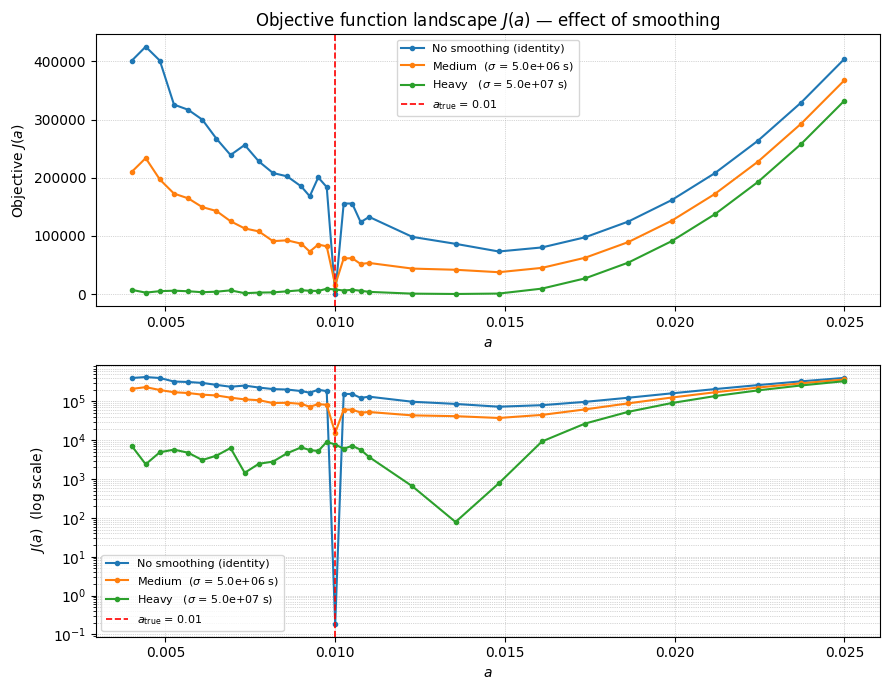


No smoothing (identity)                             min J = 1.809e-01  at a = 0.01000
Medium  ($\sigma$ = 5.0e+06 s)                      min J = 1.555e+04  at a = 0.01000
Heavy   ($\sigma$ = 5.0e+07 s)                      min J = 7.850e+01  at a = 0.01355


In [88]:
# ------------------------------------------------------------------
# Objective function landscape: J(a) for three smoothing levels
# ------------------------------------------------------------------
a_true_val = M_true['a']

# Local Gaussian builder — bypasses the identity override in make_smoothing_matrix
def gaussian_S(t, sigma):
    """Row-normalised Gaussian smoothing kernel on an arbitrary time grid."""
    diff2 = (t[:, None] - t[None, :]) ** 2 / (2.0 * sigma ** 2)
    S = np.exp(-diff2)
    S /= S.sum(axis=1, keepdims=True)
    return S

def compute_J_S(fwd, t_obs, u_obs, S):
    """J = 0.5 * int_0^T (Su - Su_obs)^2 dt  with a pre-built S matrix."""
    u_obs_at_fwd = np.interp(fwd['t'], t_obs, u_obs)
    Su     = S @ fwd['u']
    Su_obs = S @ u_obs_at_fwd
    return 0.5 * np.trapz((Su - Su_obs) ** 2, fwd['t'])

# Three smoothing levels
sigma_medium = 0.01 * T    # ~58  days  (matches sigma_smooth used elsewhere)
sigma_heavy  = 0.10 * T    # ~580 days

smoothing_cases = [
    ('No smoothing (identity)',                       None,         'C0'),
    (f'Medium  ($\\sigma$ = {sigma_medium:.1e} s)',   sigma_medium, 'C1'),
    (f'Heavy   ($\\sigma$ = {sigma_heavy:.1e} s)',    sigma_heavy,  'C2'),
]

# a values to scan — denser near the truth
a_scan = np.concatenate([
    np.linspace(0.4 * a_true_val, 0.9 * a_true_val, 12, endpoint=False),
    np.linspace(0.9 * a_true_val, 1.1 * a_true_val,  8, endpoint=False),
    np.linspace(1.1 * a_true_val, 2.5 * a_true_val, 12),
])

# --- Run all forward solves once (expensive), cache results ---
print(f"Caching {len(a_scan)} forward solves  [a_true = {a_true_val:.4f}] ...")
fwd_cache = []
for i, a_val in enumerate(a_scan):
    Mc = dict(M_true)
    Mc['a'] = a_val
    try:
        fwd_s = forward_solve_adaptive(Mc, T, u_init, psi_init)
    except Exception as e:
        fwd_s = None
        print(f"  a={a_val:.5f} failed: {e}")
    fwd_cache.append(fwd_s)
    if (i + 1) % 8 == 0 or i == len(a_scan) - 1:
        print(f"  [{i+1}/{len(a_scan)}]  a={a_val:.5f}")

# --- Evaluate J for each smoothing level using the cached forward solves ---
J_results = {}
for label, sigma, _ in smoothing_cases:
    J_arr = []
    for fwd_s in fwd_cache:
        if fwd_s is None:
            J_arr.append(np.nan)
            continue
        S = np.identity(len(fwd_s['t'])) if sigma is None else gaussian_S(fwd_s['t'], sigma)
        J_arr.append(compute_J_S(fwd_s, t_obs_arr, u_obs, S))
    J_results[label] = np.array(J_arr)

# ------------------------------------------------------------------
# Plot: one line per smoothing level, linear + log panels
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(9, 7))

for label, sigma, color in smoothing_cases:
    J_arr = J_results[label]
    J_pos = np.where(J_arr > 0, J_arr, np.nan)
    axes[0].plot(a_scan, J_arr,  'o-', ms=3, lw=1.5, color=color, label=label)
    axes[1].semilogy(a_scan, J_pos, 'o-', ms=3, lw=1.5, color=color, label=label)

for ax in axes:
    ax.axvline(a_true_val, color='red', ls='--', lw=1.2,
               label=f'$a_{{\\rm true}}$ = {a_true_val}')
    ax.legend(fontsize=8)
    ax.grid(True, ls=':', lw=0.5, which='both')
    ax.set_xlabel('$a$')

axes[0].set_ylabel('Objective $J(a)$')
axes[0].set_title('Objective function landscape $J(a)$ — effect of smoothing')
axes[1].set_ylabel('$J(a)$  (log scale)')

plt.tight_layout()
plt.savefig('Figures/J_landscape_a_smoothing.png', dpi=150, bbox_inches='tight')
plt.show()

print()
for label, sigma, _ in smoothing_cases:
    J_arr = J_results[label]
    imin  = np.nanargmin(J_arr)
    print(f"{label:50s}  min J = {J_arr[imin]:.3e}  at a = {a_scan[imin]:.5f}")

## Simple Gradient Descent: Recover True $a$

Start at $a = 1.1\,a_{\rm true}$, take gradient steps $a \leftarrow a - \alpha\,dJ/da$.

The step size is kept fixed (chosen so early steps don't overshoot).

In [82]:
a_true_val = M_true['a']
a_curr     = a_true_val * 1.1

a_min = 1e-4
a_max = 10 * a_true_val

alpha_init = abs(a_curr) / abs(grad_adj) * 0.01

n_iter    = 15
J_hist    = []
a_hist    = [a_curr]
grad_hist = []
u_hist    = []
t_hist    = []

a_prev    = None
grad_prev = None

for it in range(n_iter):
    Mc = dict(M_true)
    Mc['a'] = a_curr

    fwd_it  = forward_solve_adaptive(Mc, T, u_init, psi_init)
    J_it    = compute_J(fwd_it, t_obs_arr, u_obs, sigma_smooth)
    adj_it  = adjoint_solve(fwd_it, t_obs_arr, u_obs, Mc, sigma_smooth)
    grad_it = compute_grad_a(fwd_it, adj_it, Mc)

    J_hist.append(J_it)
    grad_hist.append(grad_it)
    u_hist.append(fwd_it['u'].copy())
    t_hist.append(fwd_it['t'].copy())

    # Barzilai-Borwein step size, capped at 30% of current |a|
    if a_prev is None or abs(grad_it - grad_prev) < 1e-30:
        alpha = alpha_init
    else:
        alpha_bb  = abs((a_curr - a_prev) / (grad_it - grad_prev))
        alpha_cap = 0.30 * abs(a_curr) / (abs(grad_it) + 1e-30)
        alpha = min(alpha_bb, alpha_cap)

    a_prev    = a_curr
    grad_prev = grad_it

    # Backtracking line search
    found = False
    a_try = a_curr
    for bt in range(12):
        a_try = float(np.clip(a_curr - alpha * grad_it, a_min, a_max))
        try:
            Mc_try = dict(M_true)
            Mc_try['a'] = a_try
            forward_solve_adaptive(Mc_try, T, u_init, psi_init)
            found = True
            break
        except (ValueError, RuntimeError):
            alpha *= 0.5

    bt_note = (f"  [backtracked {bt}x, α→{alpha:.3e}]" if (found and bt > 0)
               else ("  [backtracking exhausted]" if not found else ""))

    if not found:
        a_try = a_curr

    a_curr = a_try
    a_hist.append(a_curr)

    print(f"iter {it+1:3d}: J={J_it:.4e},  a={a_curr:.6f},  "
          f"a_err={abs(a_curr-a_true_val)/a_true_val*100:.3f}%,  "
          f"α={alpha:.3e},  dJ/da={grad_it:.4e}{bt_note}")
    if abs(grad_it) < 1e-8: break
    if not found: break

iter   1: J=1.3264e+05,  a=0.010890,  a_err=8.900%,  α=6.083e-64,  dJ/da=1.8082e+59
iter   2: J=1.3226e+05,  a=0.010016,  a_err=0.158%,  α=5.443e-63,  dJ/da=1.6061e+59
iter   3: J=7.2755e+04,  a=0.010016,  a_err=0.158%,  α=5.443e-63,  dJ/da=1.0915e+55
iter   4: J=7.2734e+04,  a=0.010016,  a_err=0.155%,  α=1.765e-62,  dJ/da=1.4282e+55
iter   5: J=7.2664e+04,  a=0.010015,  a_err=0.149%,  α=6.087e-62,  dJ/da=1.0142e+55
iter   6: J=7.2455e+04,  a=0.010009,  a_err=0.093%,  α=4.928e-61,  dJ/da=1.1395e+55
iter   7: J=6.8292e+04,  a=0.009975,  a_err=0.254%,  α=3.535e-60,  dJ/da=9.8061e+54
iter   8: J=1.0175e+05,  a=0.009969,  a_err=0.312%,  α=4.129e-60,  dJ/da=1.4106e+54
iter   9: J=1.0454e+05,  a=0.009956,  a_err=0.441%,  α=5.023e-60,  dJ/da=2.5702e+54
iter  10: J=1.1124e+05,  a=0.009936,  a_err=0.644%,  α=2.865e-60,  dJ/da=7.0769e+54
iter  11: J=1.2125e+05,  a=0.009849,  a_err=1.509%,  α=9.365e-60,  dJ/da=9.2414e+54
iter  12: J=1.5796e+05,  a=0.009078,  a_err=9.218%,  α=7.405e-59,  dJ/da=1.0

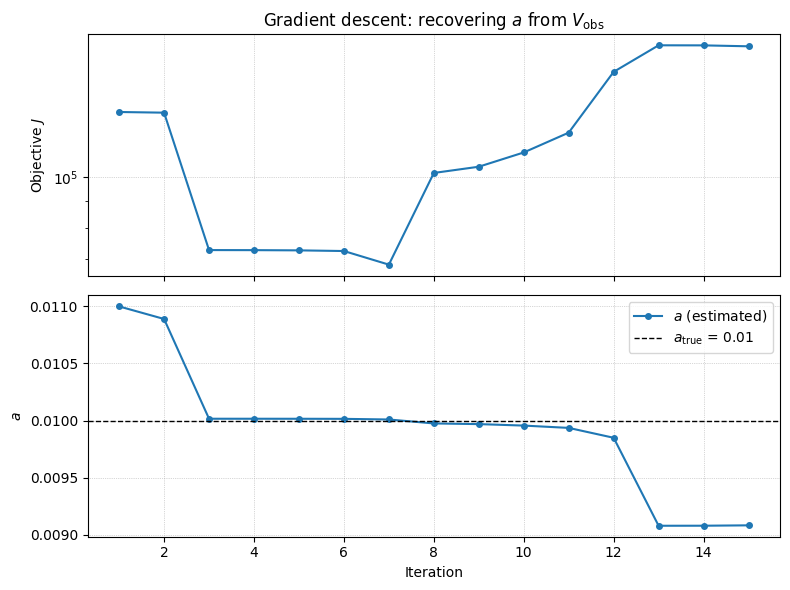


Final a = 0.009092  (true a = 0.010000,  error = 9.0807%)


In [83]:
# ------------------------------------------------------------------
# Plot 4: Gradient descent convergence
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

iters = np.arange(1, n_iter + 1)

axes[0].semilogy(iters, J_hist, 'o-', ms=4)
axes[0].set_ylabel('Objective $J$')
axes[0].set_title('Gradient descent: recovering $a$ from $V_{\\rm obs}$')
axes[0].grid(True, ls=':', lw=0.5)

axes[1].plot(iters, a_hist[:-1], 'o-', ms=4, label='$a$ (estimated)')
axes[1].axhline(a_true_val, color='k', ls='--', lw=1.0, label=f'$a_{{\\rm true}}$ = {a_true_val}')
axes[1].set_ylabel('$a$')
axes[1].set_xlabel('Iteration')
axes[1].legend()
axes[1].grid(True, ls=':', lw=0.5)

plt.tight_layout()
plt.show()

print(f"\nFinal a = {a_hist[-1]:.6f}  (true a = {a_true_val:.6f},  "
      f"error = {abs(a_hist[-1]-a_true_val)/a_true_val*100:.4f}%)")

Saving animation... this may take a moment.


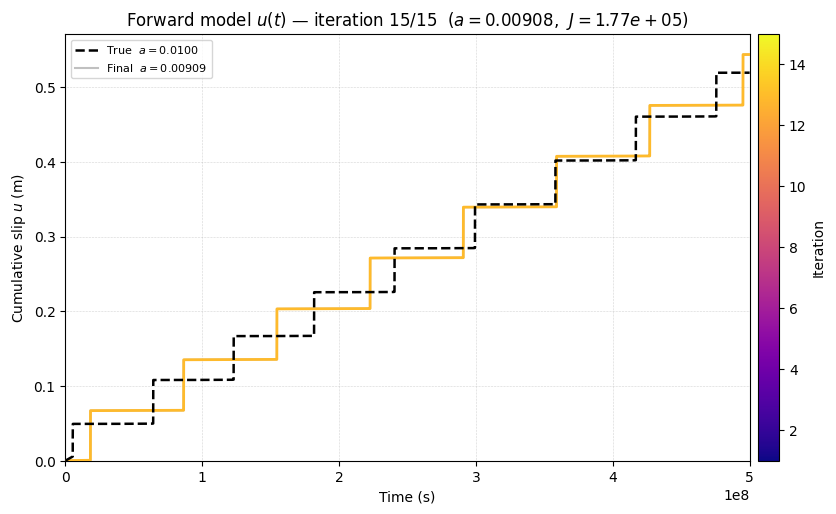

In [86]:
# ------------------------------------------------------------------
# Plot 5 (animated): cycle through gradient descent iterations.
# ------------------------------------------------------------------
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig_anim, ax_anim = plt.subplots(figsize=(9, 5))

ax_anim.plot(t_obs_arr, u_obs, 'k--', lw=1.8,
             label=f'True  $a={a_true_val:.4f}$', zorder=5)

line_final, = ax_anim.plot(t_hist[-1], u_hist[-1], color='silver', lw=1.5,
                            ls='-', label=f'Final  $a={a_hist[n_iter]:.5f}$', zorder=2)

cmap_anim = plt.cm.plasma
line_curr, = ax_anim.plot([], [], lw=2.0, zorder=4)

sm = plt.cm.ScalarMappable(cmap=cmap_anim,
     norm=plt.Normalize(vmin=1, vmax=n_iter))
sm.set_array([])
cbar_anim = fig_anim.colorbar(sm, ax=ax_anim, pad=0.01)
cbar_anim.set_label('Iteration')

ax_anim.set_xlabel('Time (s)')
ax_anim.set_ylabel('Cumulative slip $u$ (m)')
ax_anim.grid(True, ls=':', lw=0.4, which='both')

all_u = np.concatenate(u_hist + [u_obs])
ax_anim.set_ylim(all_u.min() * 0.95, all_u.max() * 1.05)
ax_anim.set_xlim(t_obs_arr[0], t_obs_arr[-1])
ax_anim.legend(fontsize=8, loc='upper left')
title_obj = ax_anim.set_title('')

def _init():
    line_curr.set_data([], [])
    return line_curr, title_obj

def _update(frame):
    idx   = frame
    color = cmap_anim((idx) / max(n_iter - 1, 1) * 0.75 + 0.1)
    line_curr.set_data(t_hist[idx], u_hist[idx])
    line_curr.set_color(color)
    title_obj.set_text(
        f'Forward model $u(t)$ — iteration {idx+1}/{n_iter}  '
        f'($a={a_hist[idx]:.5f}$,  $J={J_hist[idx]:.2e}$)'
    )
    return line_curr, title_obj

anim = FuncAnimation(
    fig_anim, _update,
    frames=n_iter,
    init_func=_init,
    interval=600,
    blit=True,
    repeat=True,
)

plt.tight_layout()
writer = 'ffmpeg' # or 'avconv' if you prefer
print("Saving animation... this may take a moment.")
anim.save(
    'Figures/gradient_descent_evolution_adap_slip.gif', 
    writer=writer, 
    fps=3,        # Frames per second
    dpi=150,       # Image quality
    bitrate=1800   # Video bitrate (higher = better quality/larger file)
)

HTML(anim.to_jshtml())
